# Forward Selection — Customer Traffic Forecasting

Applies the forward-selection procedure from *BA222 Lecture Notes 08* (Rhoads) to the
ad-set&times;day panel:

1. Correlate every candidate variable with the target (`leads`); the highest |correlation|
   variable enters the model first.
2. Repeatedly add whichever remaining candidate raises **adjusted R&sup2;** the most.
3. Stop the moment no remaining candidate improves adjusted R&sup2; — the variables left
   out are the redundant ones.

Data: the four `Full Information Dataset` workbooks (`06-06 to 07-10`, `07-11 to 07-17`,
`07-18 to 07-24`, `07-25 to 08-01`), `ad_set_days` sheet — the ad-set&times;day grain used
for the project's declared-variable OLS panel (see `Vault/Modeling/OLS-Declared-Ten-Variables.md`).

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

## 1. Load and pool the four datasets

Each workbook covers a non-overlapping date range on the same `ad_set_id` grain, so they
concatenate cleanly (verified: zero duplicate `(ad_set_id, date)` pairs across the four files).

In [2]:
DATA_DIR = Path("Dataset/Datsaa/Dataset Template/Full Information Dataset")

DATASET_FILES = [
    "Dataset 06-06 to 07-10.xlsx",
    "Dataset 07-11 to 07-17.xlsx",
    "Dataset 07-18 to 07-24.xlsx",
    "Dataset 07-25 to 08-01.xlsx",
]

frames = [pd.read_excel(DATA_DIR / f, sheet_name="ad_set_days") for f in DATASET_FILES]
raw = pd.concat(frames, ignore_index=True)

assert raw.duplicated(subset=["ad_set_id", "date"]).sum() == 0, "overlapping ad_set/date rows across files"
print(f"Pooled shape: {raw.shape}")
print(f"Date range: {raw['date'].min().date()} .. {raw['date'].max().date()}")
raw.head()

Pooled shape: (879, 30)
Date range: 2026-06-06 .. 2026-07-31


,date,ad_set_id,campaign_id,campaign_name,delivery_status,leads,spend,holiday_proximity,is_holiday,days_since_adset_started,frequency,ad_change_recency,ad_set_change_recency,day_of_week,day_of_week_num,is_weekend,ad_set_change_type,ad_change_type,reach,impressions,messaging_conversations,ad_set_budget,ad_set_budget_type,cpl,cpm,zero_lead_day,ad_set_change_type_inferred,ad_set_change_recency_inferred,ad_change_type_inferred,ad_change_recency_inferred
0,2026-06-06,120235942906970078,120235942262330078,Leads | VISA | JP | FOR,active,3,3.87,60_plus_or_none,0,0,1.277090,NaN,NaN,Saturday,5,1,NaN,NaN,1292,1650,4,3.5,Daily,1.290000,2.345455,0,budget_change,0,no_recent_change,0
1,2026-06-06,120235943617030078,120235943617000078,Leads | VISA | HK | FOR,active,5,1.83,60_plus_or_none,0,0,1.403696,NaN,NaN,Saturday,5,1,NaN,NaN,1028,1443,4,5.0,Daily,0.366000,1.268191,0,budget_change,0,no_recent_change,0
2,2026-06-06,120235943617040078,120235943617000078,Leads | VISA | HK | FOR,inactive,1,1.70,60_plus_or_none,0,0,1.270567,NaN,NaN,Saturday,5,1,NaN,NaN,547,695,1,2.0,Daily,1.700000,2.446043,0,budget_change,0,no_recent_change,0
3,2026-06-06,120236217374900078,120236217374890078,Leads | VISA | AU | KHM,active,9,6.60,60_plus_or_none,0,0,1.217318,NaN,NaN,Saturday,5,1,NaN,NaN,2379,2896,11,10.0,Daily,0.733333,2.279006,0,budget_change,0,no_recent_change,0
4,2026-06-06,120236402476500078,120236402476490078,Leads | VISA | CN+HK | KHM,active,2,2.97,60_plus_or_none,0,0,1.328162,NaN,NaN,Saturday,5,1,NaN,NaN,838,1113,0,7.0,Daily,1.485000,2.668464,0,budget_change,0,no_recent_change,0


## 2. Choose target and candidate variables

Target: `leads`.

**Excluded from the candidate pool** (checked against this pooled data, not assumed):
- `date`, `ad_set_id`, `campaign_id`, `campaign_name` — identifiers, not predictors.
- `cpl` — `spend / leads`; regressing `leads` on it is target leakage. Also 161 undefined
  rows (zero-lead days).
- `zero_lead_day` — by construction `1` exactly when `leads == 0`; leakage.
- `ad_set_budget_type` — constant (`"Daily"` on every row in this data) so it has zero
  variance and no correlation is defined.
- `holiday_proximity` — perfectly redundant with `is_holiday` in this data (only two
  buckets appear, `60_plus_or_none` / `during_holiday`, a 1:1 match with `is_holiday`
  0/1). Kept `is_holiday` since it's already numeric.
- `ad_set_change_type`, `ad_change_type` (the raw, non-inferred columns) — 100% NaN in
  this export; every row's change type is only populated in the `..._inferred` columns.
  See `Vault/Data-Pipeline/Master-Dataset.md`.

**Categorical candidates** get one-hot encoded with an explicit held-out reference level
(the modal / most natural baseline), matching the collinearity-avoidance convention this
project already uses for OLS (`Vault/Modeling/OLS-Declared-Ten-Variables.md`):
- `day_of_week` → 6 dummies, reference = `Monday`.
- `delivery_status` → 1 dummy, reference = `active` (808/879 rows).
- `ad_set_change_type_inferred` → 3 dummies, reference = `budget_change` (modal, 480/879).
- `ad_change_type_inferred` → 4 dummies, reference = `no_recent_change`.

Every dummy is treated as its own candidate variable for forward selection — the same
per-column treatment the lecture notes' loop-based implementation (Section 4) uses, and
what this project's own OLS panel already does for weekday/change-type dummies.

In [3]:
TARGET = "leads"

NUMERIC_CANDIDATES = [
    "spend",
    "reach",
    "impressions",
    "messaging_conversations",
    "frequency",
    "ad_set_budget",
    "cpm",
    "is_holiday",
    "days_since_adset_started",
    "is_weekend",
    "ad_set_change_recency_inferred",
    "ad_change_recency_inferred",
]

# (column, reference level to drop)
CATEGORICAL_CANDIDATES = [
    ("day_of_week", "Monday"),
    ("delivery_status", "active"),
    ("ad_set_change_type_inferred", "budget_change"),
    ("ad_change_type_inferred", "no_recent_change"),
]


def slugify(name: str) -> str:
    return re.sub(r"\W+", "_", name.strip()).strip("_")


df_model = raw[[TARGET] + NUMERIC_CANDIDATES].copy()
df_model = df_model.dropna()  # cpm has 1 NaN row in this data

dummy_cols = []
for col, reference in CATEGORICAL_CANDIDATES:
    levels = [reference] + sorted(l for l in raw[col].unique() if l != reference)
    coded = pd.Categorical(raw.loc[df_model.index, col], categories=levels)
    dummies = pd.get_dummies(coded, prefix=col, drop_first=True).astype(int)
    dummies.columns = [slugify(c) for c in dummies.columns]
    dummies.index = df_model.index
    df_model = pd.concat([df_model, dummies], axis=1)
    dummy_cols.extend(dummies.columns)

CANDIDATE_VARS = NUMERIC_CANDIDATES + dummy_cols

print(f"Rows after dropping NaNs: {len(df_model)} (of {len(raw)})")
print(f"Candidate variables ({len(CANDIDATE_VARS)}):")
for v in CANDIDATE_VARS:
    print(f"  - {v}")

Rows after dropping NaNs: 878 (of 879)
Candidate variables (26):
  - spend
  - reach
  - impressions
  - messaging_conversations
  - frequency
  - ad_set_budget
  - cpm
  - is_holiday
  - days_since_adset_started
  - is_weekend
  - ad_set_change_recency_inferred
  - ad_change_recency_inferred
  - day_of_week_Friday
  - day_of_week_Saturday
  - day_of_week_Sunday
  - day_of_week_Thursday
  - day_of_week_Tuesday
  - day_of_week_Wednesday
  - delivery_status_inactive
  - ad_set_change_type_inferred_bid_change
  - ad_set_change_type_inferred_placement_change
  - ad_set_change_type_inferred_targeting_change
  - ad_change_type_inferred_ad_added
  - ad_change_type_inferred_ad_paused
  - ad_change_type_inferred_ad_swapped
  - ad_change_type_inferred_msg_template_change


## 3. Steps 1-2 — correlation with the target

Per the lecture notes, the first variable entered is whichever candidate has the highest
*absolute* correlation with `leads`.

In [4]:
target_corr = df_model[CANDIDATE_VARS].corrwith(df_model[TARGET])
target_corr = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
target_corr.to_frame("correlation_with_leads")

,correlation_with_leads
messaging_conversations,0.949434
ad_set_budget,0.666582
spend,0.657001
ad_set_change_type_inferred_placement_change,0.485126
reach,0.313237
impressions,0.303222
ad_change_recency_inferred,-0.202850
days_since_adset_started,0.181485
delivery_status_inactive,-0.181229
ad_change_type_inferred_ad_paused,0.143247


## 4. Steps 3-5 — greedy add by adjusted R&sup2;

`forward_selection` fits an OLS model for every remaining candidate added to the current
set, keeps whichever addition gives the highest adjusted R&sup2;, and stops as soon as no
candidate improves on the current best — exactly the stopping rule in Section 3.1.

In [5]:
def fit_ols(df: pd.DataFrame, y_col: str, x_cols: list[str]):
    X = sm.add_constant(df[x_cols])
    return sm.OLS(df[y_col], X).fit()


def forward_selection(df: pd.DataFrame, y_col: str, candidates: list[str]):
    """Rhoads LN08 Section 3.1: correlation-seeded, adjusted-R2-greedy forward selection."""
    remaining = list(candidates)

    # Steps 1-2: seed with the highest-|correlation| variable.
    corr = df[remaining].corrwith(df[y_col]).abs()
    first = corr.idxmax()
    selected = [first]
    remaining.remove(first)
    best_adj_r2 = fit_ols(df, y_col, selected).rsquared_adj

    history = [{"step": 1, "added": first, "adj_r2": best_adj_r2, "reason": "highest |correlation|"}]

    # Steps 3-5: repeatedly add whichever candidate raises adjusted R2 the most.
    step = 2
    while remaining:
        trial_scores = {
            col: fit_ols(df, y_col, selected + [col]).rsquared_adj for col in remaining
        }
        best_col = max(trial_scores, key=trial_scores.get)
        if trial_scores[best_col] <= best_adj_r2:
            break  # Step 5: no candidate improves adjusted R2 -> stop
        selected.append(best_col)
        remaining.remove(best_col)
        best_adj_r2 = trial_scores[best_col]
        history.append({"step": step, "added": best_col, "adj_r2": best_adj_r2, "reason": "max adjusted R2 gain"})
        step += 1

    return selected, remaining, pd.DataFrame(history)


selected_vars, redundant_vars, selection_history = forward_selection(df_model, TARGET, CANDIDATE_VARS)
selection_history

,step,added,adj_r2,reason
0,1,messaging_conversations,0.901312,highest |correlation|
1,2,ad_set_change_type_inferred_placement_change,0.902980,max adjusted R2 gain
2,3,impressions,0.904415,max adjusted R2 gain
3,4,ad_change_type_inferred_ad_swapped,0.904878,max adjusted R2 gain
4,5,ad_set_budget,0.905298,max adjusted R2 gain
5,6,ad_change_type_inferred_msg_template_change,0.905601,max adjusted R2 gain
6,7,ad_change_type_inferred_ad_paused,0.905831,max adjusted R2 gain
7,8,ad_set_change_recency_inferred,0.906014,max adjusted R2 gain
8,9,day_of_week_Friday,0.906147,max adjusted R2 gain
9,10,reach,0.906226,max adjusted R2 gain


## 5. Result

In [6]:
print("Selected, in the order added (variable : adjusted R2 after adding it):")
for row in selection_history.itertuples():
    print(f"  {row.step}. {row.added:<40s} adj R2 = {row.adj_r2:.4f}")

print(f"\nFinal adjusted R2: {selection_history['adj_r2'].iloc[-1]:.4f}")
print(f"\nRedundant variables (never improved adjusted R2, left out): {len(redundant_vars)}")
for v in redundant_vars:
    print(f"  - {v}")

Selected, in the order added (variable : adjusted R2 after adding it):
  1. messaging_conversations                  adj R2 = 0.9013
  2. ad_set_change_type_inferred_placement_change adj R2 = 0.9030
  3. impressions                              adj R2 = 0.9044
  4. ad_change_type_inferred_ad_swapped       adj R2 = 0.9049
  5. ad_set_budget                            adj R2 = 0.9053
  6. ad_change_type_inferred_msg_template_change adj R2 = 0.9056
  7. ad_change_type_inferred_ad_paused        adj R2 = 0.9058
  8. ad_set_change_recency_inferred           adj R2 = 0.9060
  9. day_of_week_Friday                       adj R2 = 0.9061
  10. reach                                    adj R2 = 0.9062
  11. frequency                                adj R2 = 0.9064

Final adjusted R2: 0.9064

Redundant variables (never improved adjusted R2, left out): 15
  - spend
  - cpm
  - is_holiday
  - days_since_adset_started
  - is_weekend
  - ad_change_recency_inferred
  - day_of_week_Saturday
  - day_of_wee

## 6. Final model — full statsmodels summary

In [7]:
final_model = fit_ols(df_model, TARGET, selected_vars)
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  leads   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                     773.0
Date:                Sat, 08 Aug 2026   Prob (F-statistic):               0.00
Time:                        14:57:59   Log-Likelihood:                -1382.9
No. Observations:                 878   AIC:                             2790.
Df Residuals:                     866   BIC:                             2847.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

## 7. Adjusted R&sup2; progression

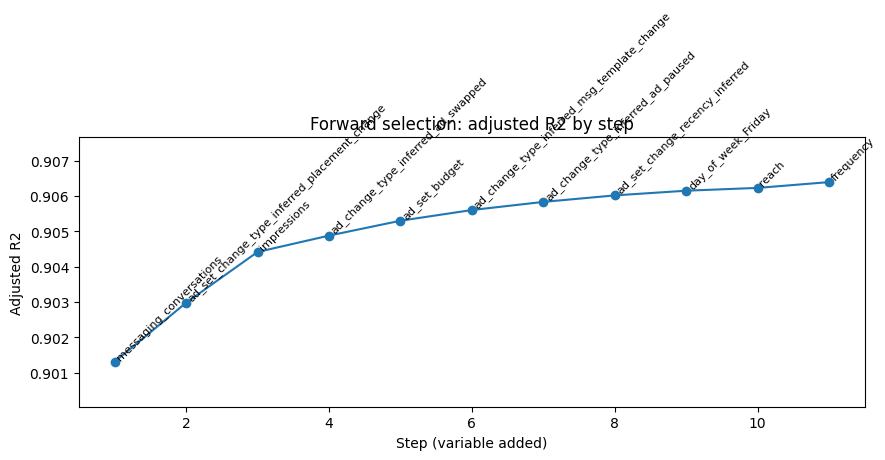

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(selection_history["step"], selection_history["adj_r2"], marker="o")
for row in selection_history.itertuples():
    ax.annotate(row.added, (row.step, row.adj_r2), rotation=45, ha="left", va="bottom", fontsize=8)
ax.set_xlabel("Step (variable added)")
ax.set_ylabel("Adjusted R2")
ax.set_title("Forward selection: adjusted R2 by step")
ax.margins(y=0.25)
fig.tight_layout()
plt.show()